In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
#Loading the Data set 
df = pd.read_excel("../data/Pizza_Sales_Dataset.xlsx")

In [5]:
df.head()

,Date,Pizza_Name,Category,Pizza_Code,Price_USD,Sales,Unsold,Revenue,Rating
0,01 January 2022,Deluxe,Non-Veg,4,15,61,7,915,Average Seller
1,01 January 2022,Double Cheese,Veg,5,9,68,9,612,Average Seller
2,01 January 2022,Farmhouse,Veg,3,7,284,23,1988,Top Seller
3,02 January 2023,Deluxe,Non-Veg,4,15,133,9,1995,Top Seller
4,02 January 2023,Double Cheese,Veg,5,9,194,21,1746,Top Seller


In [6]:
# 1. Check the number of pizzas

In [7]:
df["Pizza_Name"].unique().tolist()

['Deluxe', 'Double Cheese', 'Farmhouse', 'Chicago', 'Margherita']

In [8]:
df["Pizza_Name"].value_counts()

Pizza_Name
Farmhouse        17
Deluxe           14
Double Cheese    12
Chicago          11
Margherita        7
Name: count, dtype: int64

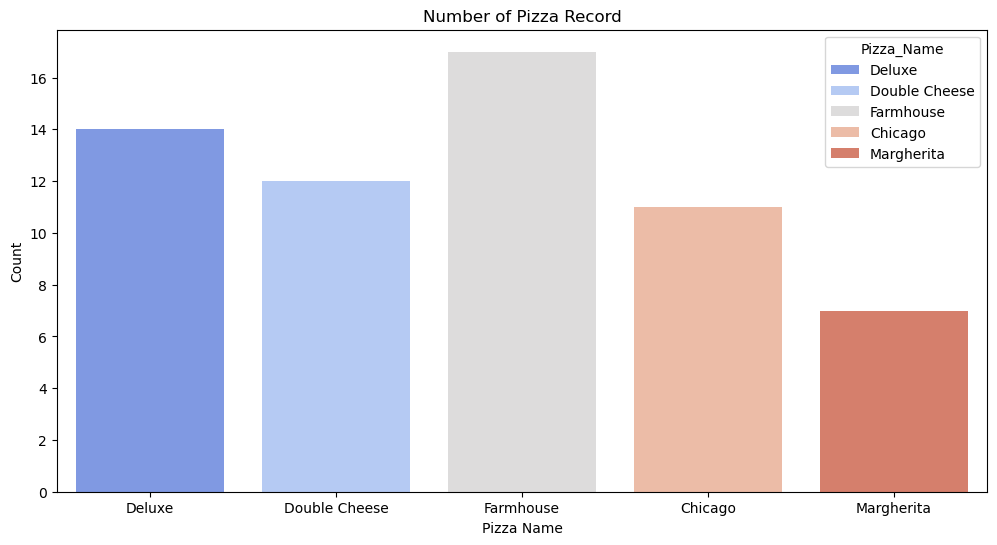

In [9]:
plt.figure(figsize = (12,6))

sns.countplot(
    data = df,
    x = "Pizza_Name" , palette = 'coolwarm' , legend = True , hue = 'Pizza_Name')

plt.title("Number of Pizza Record")
plt.xlabel("Pizza Name")
plt.ylabel("Count")
plt.show()


In [10]:
#2 Veg vs Non veg

In [11]:
df['Category'].value_counts()

Category
Veg        36
Non-Veg    25
Name: count, dtype: int64

Text(0.5, 1.0, 'Veg Vs NonVeg')

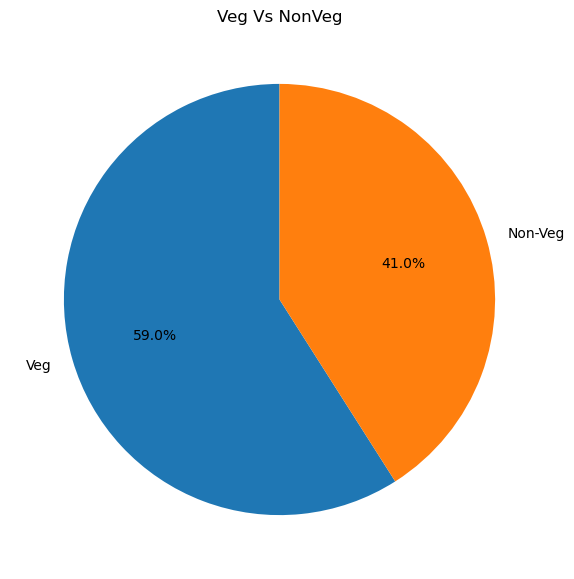

In [12]:
Category_count = df['Category'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(Category_count.values,
       labels = Category_count.index,
        autopct="%1.1f%%",
    startangle=90
)

plt.title("Veg Vs NonVeg")

In [13]:
#3 Which Pizza sells the most 

pizza_sales = df.groupby("Pizza_Name")["Sales"].sum().sort_values(ascending = False)

print(pizza_sales)

Pizza_Name
Farmhouse        3393
Deluxe           2552
Double Cheese    1916
Chicago          1600
Margherita        919
Name: Sales, dtype: int64


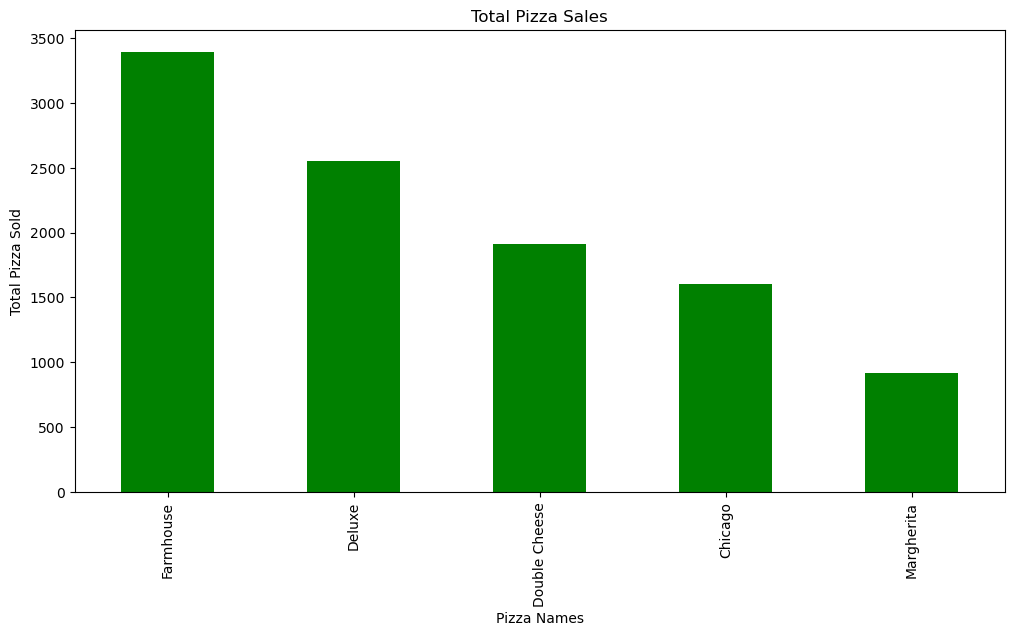

In [14]:
plt.figure(figsize=(12,6))

pizza_sales.plot(kind = 'bar' ,  color = 'Green')

plt.title("Total Pizza Sales")
plt.xlabel("Pizza Names")
plt.ylabel("Total Pizza Sold")

plt.show()

In [15]:
#the best seller
pizza_sales.idxmax()

'Farmhouse'

In [16]:
#sales
pizza_sales.max()

3393

In [17]:
#4. Which pizza generates the highest revenue?

In [18]:
pizza_revenue = (
    df.groupby("Pizza_Name")["Revenue"].sum().sort_values(ascending  =False))
pizza_revenue

Pizza_Name
Deluxe           38280
Farmhouse        23751
Double Cheese    17244
Chicago          16000
Margherita        7352
Name: Revenue, dtype: int64

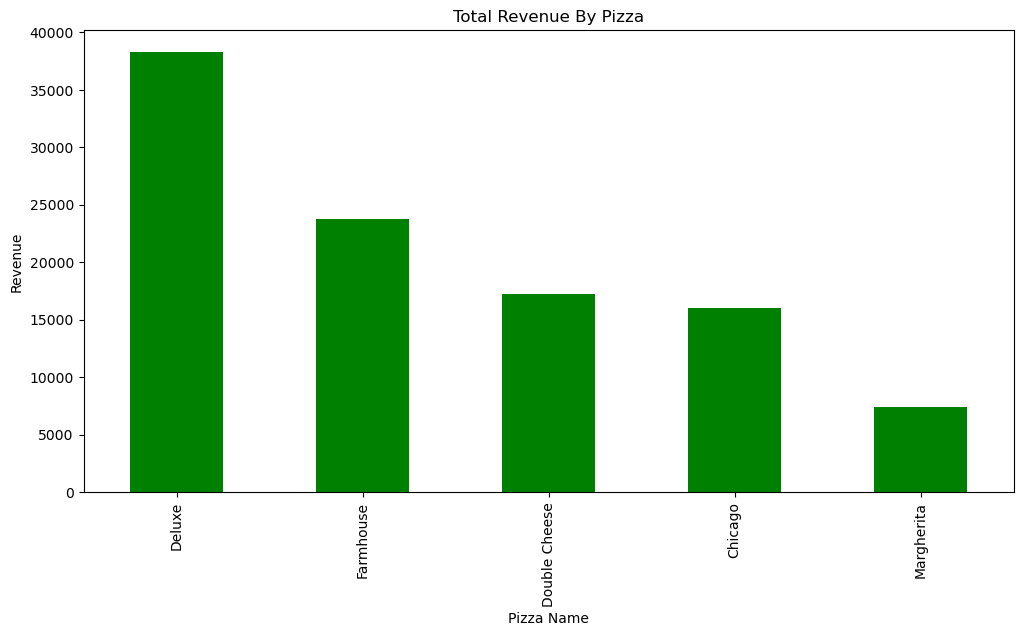

In [19]:
plt.figure(figsize=(12,6))

pizza_revenue.plot(kind = "bar" , color = "green")

plt.title("Total Revenue By Pizza")
plt.xlabel("Pizza Name")
plt.ylabel("Revenue")
plt.show()

In [20]:
#Highest Revenue Pizza
pizza_revenue.idxmax()

'Deluxe'

In [21]:
#Highest Revenue 
pizza_revenue.max()

38280

In [22]:
#5. Which pizza has the highest unsold quantity?

In [23]:
pizza_unsold = (df.groupby("Pizza_Name")["Unsold"].sum().sort_values(ascending= False))
pizza_unsold

Pizza_Name
Farmhouse        237
Deluxe           158
Chicago          154
Double Cheese    154
Margherita       124
Name: Unsold, dtype: int64

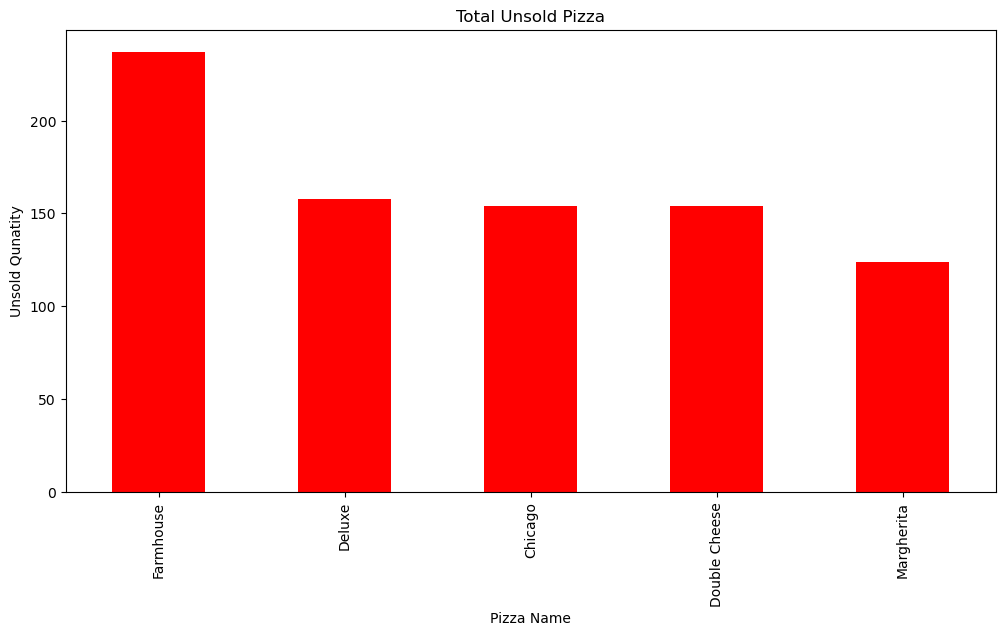

In [24]:
plt.figure(figsize=(12,6))

pizza_unsold.plot(kind = "bar" , color = "red")

plt.title("Total Unsold Pizza")
plt.xlabel("Pizza Name")
plt.ylabel("Unsold Qunatity")

plt.show()

In [25]:
#most unsold pizza name 
pizza_unsold.idxmax()

'Farmhouse'

In [26]:
#Price analysis 

In [27]:
df["Price_USD"].describe()

count    61.000000
mean      9.885246
std       3.006096
min       7.000000
25%       7.000000
50%       9.000000
75%      10.000000
max      15.000000
Name: Price_USD, dtype: float64

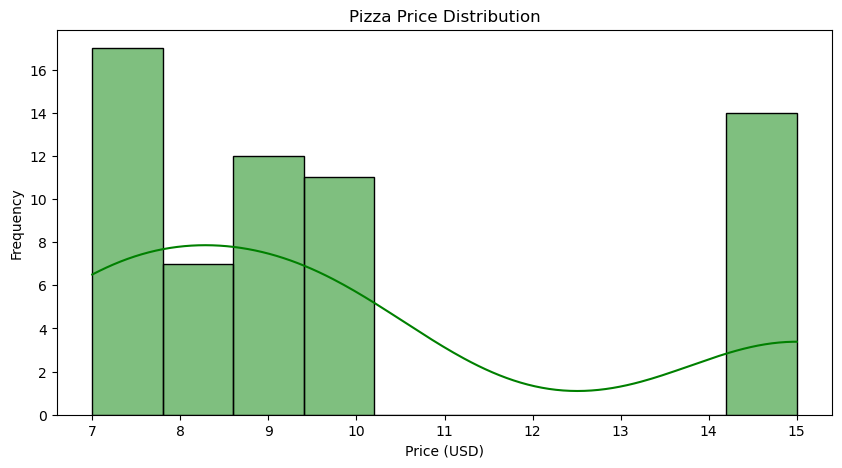

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(data=df , x = "Price_USD" , bins = 10 , kde = True , color = 'green')

plt.title("Pizza Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")

plt.show()

In [31]:
#Sales Distribution 

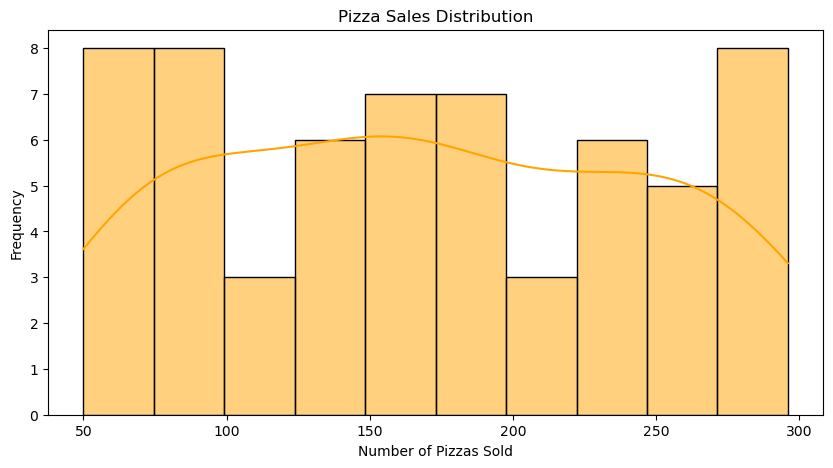

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(data = df , x = "Sales" , bins = 10 , kde =True , color = 'orange')

plt.title("Pizza Sales Distribution")
plt.xlabel("Number of Pizzas Sold")
plt.ylabel("Frequency")

plt.show()

In [34]:
#Revenue Distribution

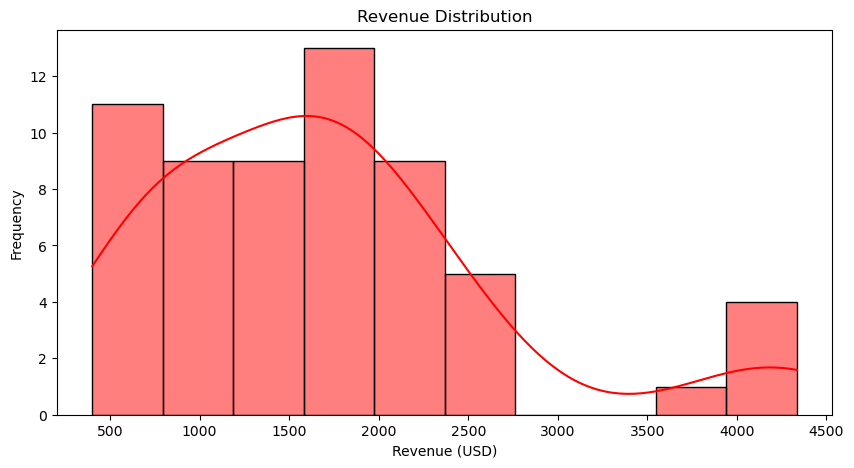

In [35]:
plt.figure(figsize=(10,5))

sns.histplot( data = df , x = 'Revenue' , bins = 10, kde = True  , color = 'red')

plt.title('Revenue Distribution')
plt.xlabel('Revenue (USD)')
plt.ylabel("Frequency")

plt.show()


In [37]:
#Price vs Sales
#Does increasing the pizza price affect the number of pizzas sold?

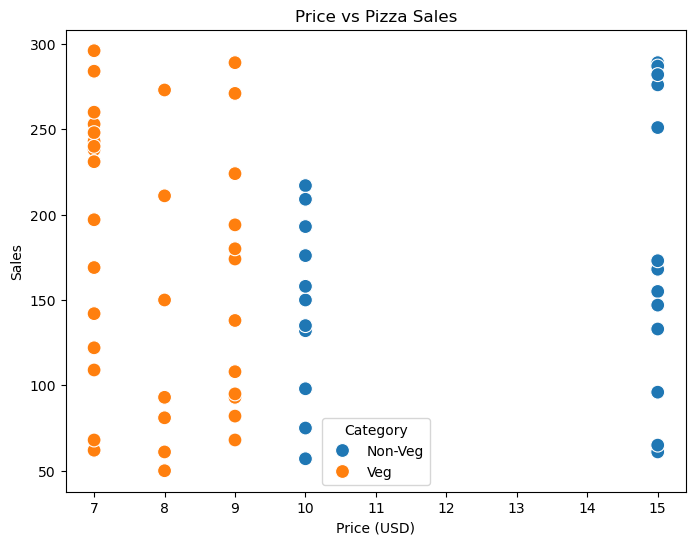

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(data = df , x = "Price_USD" , y = "Sales" , hue = "Category" , s = 100)

plt.title("Price vs Pizza Sales")
plt.xlabel("Price (USD)")
plt.ylabel("Sales")

plt.show()

In [40]:
df["Price_USD"].corr(df["Sales"])

np.float64(0.0013358049877366513)

In [ ]:
# Positive correlation → higher price tends to have higher sales
# Negative correlation → higher price tends to have lower sales
# Near 0 → little linear relationship

In [41]:
#Sales vs Revenue

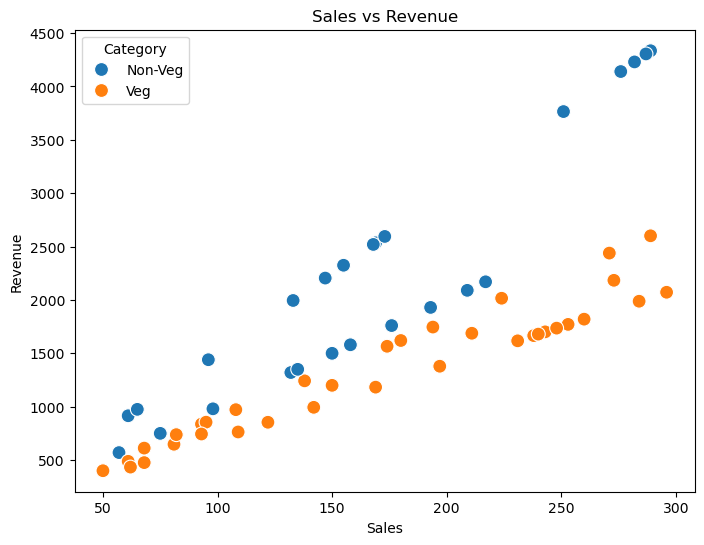

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(data = df , x= "Sales" , y = "Revenue" , hue = "Category" , s = 100)

plt.title("Sales vs Revenue")
plt.xlabel("Sales")
plt.ylabel("Revenue")

plt.show()

In [46]:
#11 Category vs Sales
#which category actually sells more?

In [47]:
category_sales = (df.groupby("Category")["Sales"].sum())

print(category_sales)
                             

Category
Non-Veg    4152
Veg        6228
Name: Sales, dtype: int64


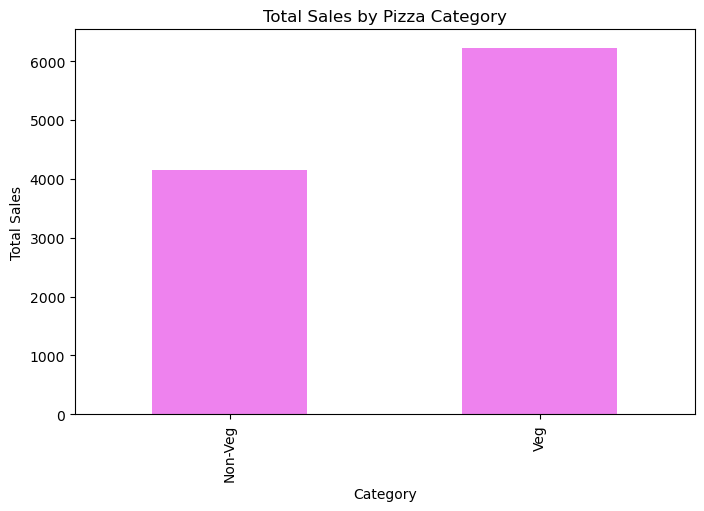

In [53]:
plt.figure(figsize=(8,5))

category_sales.plot(kind ="bar" , color = 'violet')

plt.title("Total Sales by Pizza Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [54]:
#Category vs Revenue 

In [60]:
category_revenue = (df.groupby("Category")["Revenue"].sum()
                   )
category_revenue

Category
Non-Veg    54280
Veg        48347
Name: Revenue, dtype: int64

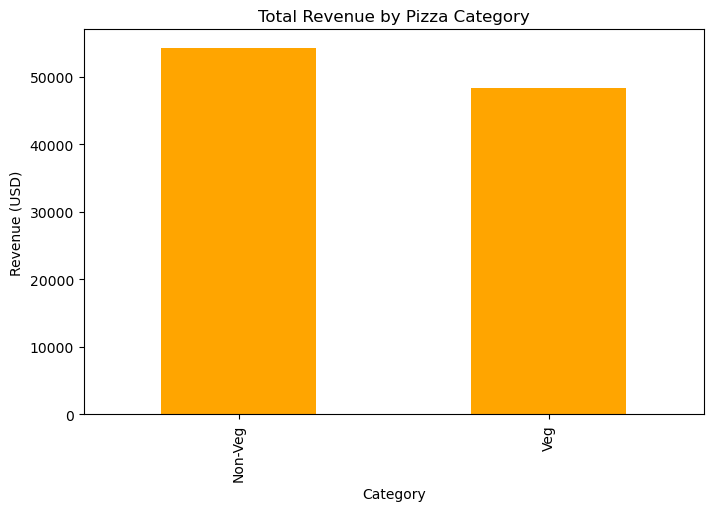

In [62]:
plt.figure(figsize = (8,5))

category_revenue.plot(kind  = 'bar' , color = 'orange')

plt.title("Total Revenue by Pizza Category")
plt.xlabel("Category")
plt.ylabel("Revenue (USD)")

plt.show()

In [63]:
#Rating Analysis 

In [64]:
df["Rating"].value_counts()

Rating
Top Seller        43
Average Seller    18
Name: count, dtype: int64

C:\Users\Prajwal\AppData\Local\Temp\ipykernel_9440\658031318.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data =df , x = "Rating",palette = 'coolwarm')


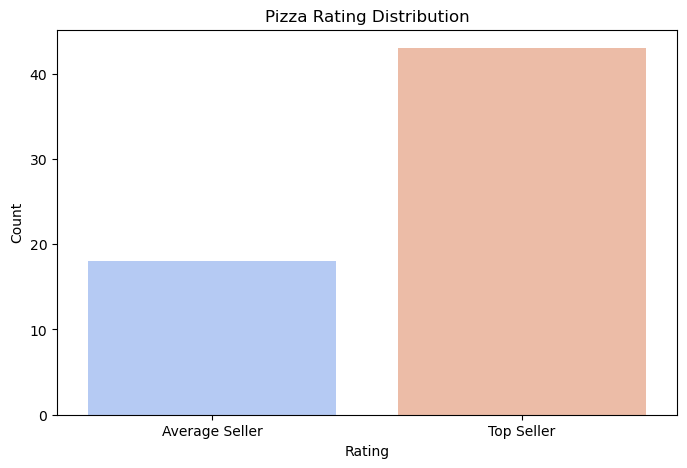

In [68]:
plt.figure(figsize = (8,5))

sns.countplot(data =df , x = "Rating",palette = 'coolwarm')

plt.title("Pizza Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [69]:
#Correlation Heatmap

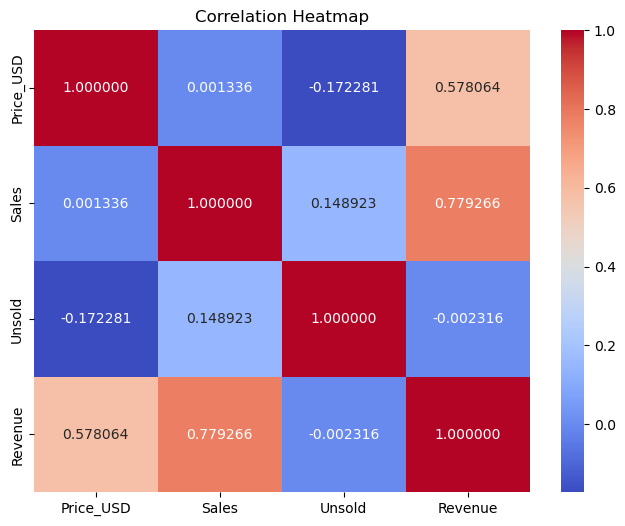

In [71]:
numeric_cols = ["Price_USD" , "Sales" , "Unsold" , "Revenue"]

corr = df[numeric_cols].corr()

plt.figure(figsize = (8,6))

sns.heatmap(corr , annot = True , cmap = 'coolwarm' , fmt = '2f')

plt.title('Correlation Heatmap')

plt.show()
